In [1]:
# 2. Setup and Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import jiwer
import matplotlib.pyplot as plt
import seaborn as plt_sns
import seaborn as sns
from datasets import load_dataset
from transformers import AutoModelForSpeechSeq2Seq, AutoProcessor
from whisper.normalizers import EnglishTextNormalizer
from sklearn.metrics import roc_auc_score
from huggingface_hub import PyTorchModelHubMixin
from tqdm import tqdm

HF_DATASET_REPO = "keylazy/slurp-noisy-asr-calibration"
HF_MODEL_REPO = "keylazy/whisper-temperature-calibrator"
AUDIO_SAMPLING_RATE = 16000

device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.backends.mps.is_available() else device
print(f"device: {device}")

normalizer = EnglishTextNormalizer()

device: cuda


In [2]:
# 3. Define the Calibrator Class
class TemperatureCalibrator(nn.Module, PyTorchModelHubMixin):
    def __init__(self):
        super().__init__()
        self.tau = nn.Parameter(torch.tensor(1.0))
        self.alpha = nn.Parameter(torch.tensor(1.0))
        self.beta = nn.Parameter(torch.tensor(1.0))

    def forward(self, word_logits_list):
        device = self.tau.device
        preds = []

        # Smoothly map tau to a space strictly > 1.0
        safe_tau = 1.0 + F.softplus(self.tau)
        
        for token_logits in word_logits_list:
            token_logits = token_logits.to(device)
            # Sanitize -inf before division to save the backward pass (and forward math)
            token_logits = torch.nan_to_num(token_logits, nan=0.0, neginf=-1e5, posinf=1e5)
            
            scaled_logits = token_logits / safe_tau
            
            probs = torch.softmax(scaled_logits, dim=-1)
            log_probs = torch.log_softmax(scaled_logits, dim=-1)
            
            neg_ent = torch.sum(probs * log_probs, dim=-1)
            word_score = torch.sum(neg_ent)
            
            pred = self.alpha * word_score + self.beta
            preds.append(pred)

        return torch.stack(preds)

In [3]:
# 4. Alignment and Inference Functions

# output: [(conf, is_correct)], e.g. [(0.8, 1), (0.3, 0)]
def align_and_label(words_conf, ground_truth):
    ref = normalizer(ground_truth).strip()

    # normalize hypothesis word by word
    cleaned_words_conf = []
    for word, conf in words_conf:
        clean_word = normalizer(word).strip()
        if clean_word:
            for sub_word in clean_word.split():
                cleaned_words_conf.append((sub_word, conf))

    hypothesis = " ".join([w for w, _ in cleaned_words_conf])

    if not hypothesis:
        return []

    out = jiwer.process_words(ref, hypothesis)
    confidences_and_labels = []

    for chunk in out.alignments[0]:
        if chunk.type == 'equal':
            for i in range(chunk.hyp_start_idx, chunk.hyp_end_idx):
                confidences_and_labels.append((cleaned_words_conf[i][1], 1))
        elif chunk.type in ['insert', 'substitute']:
            for i in range(chunk.hyp_start_idx, chunk.hyp_end_idx):
                confidences_and_labels.append((cleaned_words_conf[i][1], 0))

    return confidences_and_labels

def get_calibrated_confidences(model, processor, calibrator, audio_array, ground_truth):
    tokenizer = processor.tokenizer
    if not isinstance(audio_array, torch.Tensor):
        audio_array = torch.tensor(audio_array).float()

    inputs = processor(
        audio=audio_array,
        sampling_rate=AUDIO_SAMPLING_RATE,
        return_tensors="pt",
        return_attention_mask=True,
    ).to(model.device)

    inputs = {
        k: (v.to(model.device, dtype=model.dtype) if v.is_floating_point() else v.to(model.device))
        for k, v in inputs.items()
    }

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=200,
            return_dict_in_generate=True,
            output_scores=True,
            do_sample=False,
            num_beams=1,
            language="en",
            task="transcribe",
        )

    num_generated_tokens = len(outputs.scores)
    generated_tokens = outputs.sequences[0, -num_generated_tokens:]

    words_info = []
    current_word_str = ""
    current_word_logits = []

    for token, logit_tensor in zip(generated_tokens, outputs.scores):
        if token.item() in tokenizer.all_special_ids:
            continue

        token_str = processor.decode(token, clean_up_tokenization_spaces=False)
        token_str = token_str.replace("Ġ", " ")
        vocab_logits = logit_tensor[0].cpu()

        if token_str.startswith(" ") and current_word_str:
            words_info.append({"word": current_word_str.strip(), "logits": current_word_logits})
            current_word_str = token_str
            current_word_logits = [vocab_logits]
        else:
            current_word_str += token_str
            current_word_logits.append(vocab_logits)

    if current_word_str.strip():
        words_info.append({"word": current_word_str.strip(), "logits": current_word_logits})

    if not words_info:
        return []

    # Prepare logits for calibrator (list of stacked subword logits)
    all_word_logits = [torch.stack(w["logits"]) for w in words_info]
    
    with torch.no_grad():
        # Calibrator outputs raw logits
        calibrator_scores = calibrator(all_word_logits)
        # Convert to probabilities using sigmoid
        calibrated_confidences = torch.sigmoid(calibrator_scores).cpu().numpy()

    # Pair the generated words with their calibrated confidences
    words_conf = [(w["word"], conf) for w, conf in zip(words_info, calibrated_confidences)]

    return align_and_label(words_conf, ground_truth)


In [ ]:
# 5. Data Loading and Evaluation Loop
whisper_id = "openai/whisper-large-v3"
processor = AutoProcessor.from_pretrained(whisper_id)
model = AutoModelForSpeechSeq2Seq.from_pretrained(whisper_id, dtype=torch.float16, attn_implementation="sdpa").to(device)

# Load the trained calibrator from the Hub
calibrator = TemperatureCalibrator.from_pretrained(HF_MODEL_REPO).to(device)
calibrator.eval()

# Load Test Split
test_dataset = load_dataset(HF_DATASET_REPO, split="test")

snr_levels = ["clean", 10, 5, 0]
snr2col = {"clean": "audio_clean", 10: "audio_10dB", 5: "audio_5dB", 0: "audio_0dB"}
results = {snr: [] for snr in snr_levels}

print("\n--- Starting Evaluation on Test Set ---")
# Optional: add a `.select(range(N))` if you want to test on a smaller subset first
for item in tqdm(test_dataset):
    ground_truth = item["sentence"]

    for snr in snr_levels:
        audio_array = np.array(item[snr2col[snr]]["array"], dtype=np.float32)
        
        w_scores = get_calibrated_confidences(
            model,
            processor,
            calibrator,
            audio_array,
            ground_truth
        )
        results[snr].extend(w_scores)


model.safetensors:   0%|          | 0.00/188 [00:00<?, ?B/s]


--- Starting Evaluation on Test Set ---


100%|██████████| 100/100 [02:53<00:00,  1.74s/it]


In [5]:
# 6. Metrics Calculation
def calculate_ece(confidences, accuraries, num_bins=10):
    bins = np.linspace(0, 1, num_bins + 1)
    ece = 0.0
    for i in range(num_bins):
        bin_mask = (confidences >= bins[i]) & (confidences < bins[i + 1])
        if np.sum(bin_mask) > 0:
            bin_acc = np.mean(accuraries[bin_mask])
            bin_conf = np.mean(confidences[bin_mask])
            bin_weight = np.sum(bin_mask) / len(confidences)
            ece += bin_weight * np.abs(bin_acc - bin_conf)
    return ece

print("\n=== Final Metrics: CALIBRATED WHISPER ===")
for snr in snr_levels:
    confidences = np.array([score for score, label in results[snr]])
    labels = np.array([label for score, label in results[snr]])

    if len(np.unique(labels)) > 1:
        auroc = roc_auc_score(labels, confidences)
        ece = calculate_ece(confidences, labels)
        num_correct = np.sum(labels)
        num_wrong = len(labels) - num_correct
        print(f"[{snr} dB] AUROC: {auroc:.4f} | ECE: {ece:.4f} | (Correct: {num_correct}, Wrong: {num_wrong})")
    else:
        print(f"[{snr} dB] Either all correct or all wrong, cannot calculate AUROC.")



=== Final Metrics: CALIBRATED WHISPER ===
[clean dB] AUROC: 0.8134 | ECE: 0.0815 | (Correct: 700, Wrong: 76)
[10 dB] AUROC: 0.8268 | ECE: 0.0633 | (Correct: 658, Wrong: 127)
[5 dB] AUROC: 0.8243 | ECE: 0.0438 | (Correct: 581, Wrong: 209)
[0 dB] AUROC: 0.7627 | ECE: 0.1161 | (Correct: 400, Wrong: 382)


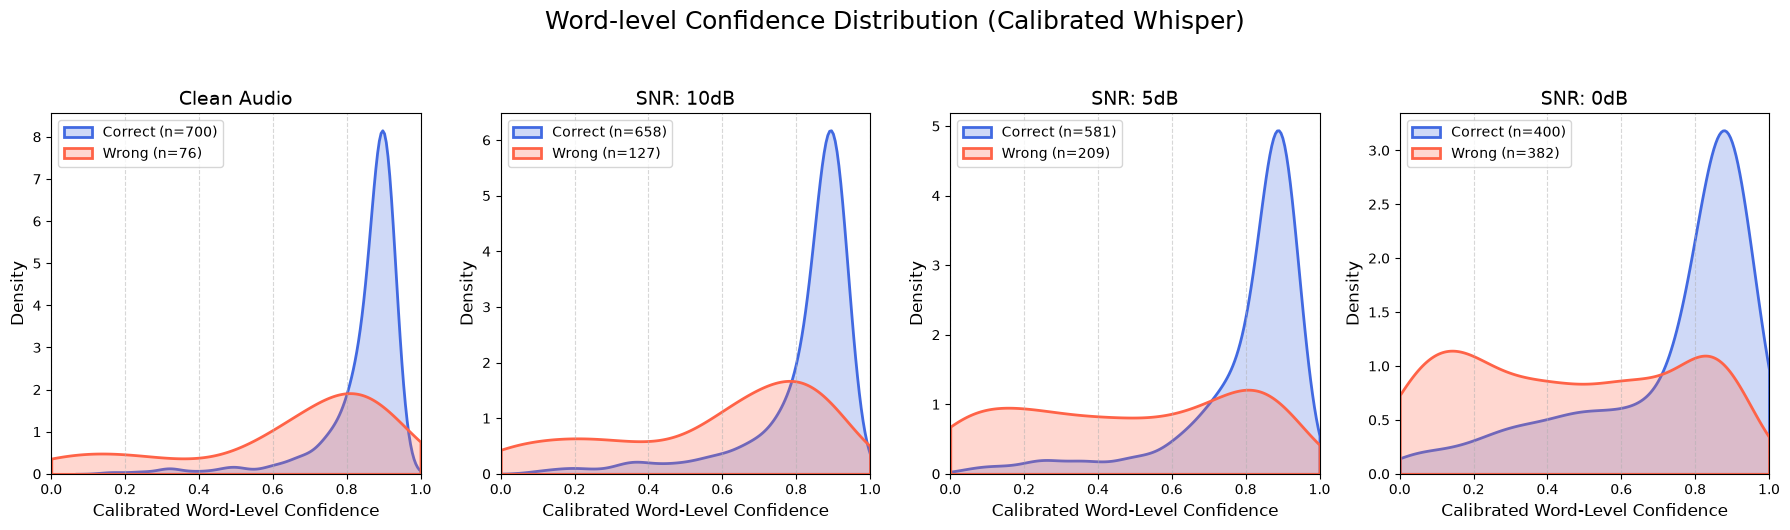

In [6]:
# 7. Plot Density Distribution
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Word-level Confidence Distribution (Calibrated Whisper)', fontsize=18, y=1.05)

for col_idx, snr in enumerate(snr_levels):
    ax = axes[col_idx]

    confidences = np.array([score for score, _ in results[snr]])
    labels = np.array([label for _, label in results[snr]])

    correct_conf = confidences[labels == 1]
    wrong_conf = confidences[labels == 0]

    if len(correct_conf) > 1:
        sns.kdeplot(
            correct_conf, fill=True, color="royalblue", label=f"Correct (n={len(correct_conf)})", 
            ax=ax, clip=(0.0, 1.0), linewidth=2
        )
    if len(wrong_conf) > 1:
        sns.kdeplot(
            wrong_conf, fill=True, color="tomato", label=f"Wrong (n={len(wrong_conf)})", 
            ax=ax, clip=(0.0, 1.0), linewidth=2
        )

    title = f"Clean Audio" if snr == "clean" else f"SNR: {snr}dB"
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Calibrated Word-Level Confidence", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_xlim(0.0, 1.0)
    ax.grid(axis="x", linestyle="--", alpha=0.5)
    ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

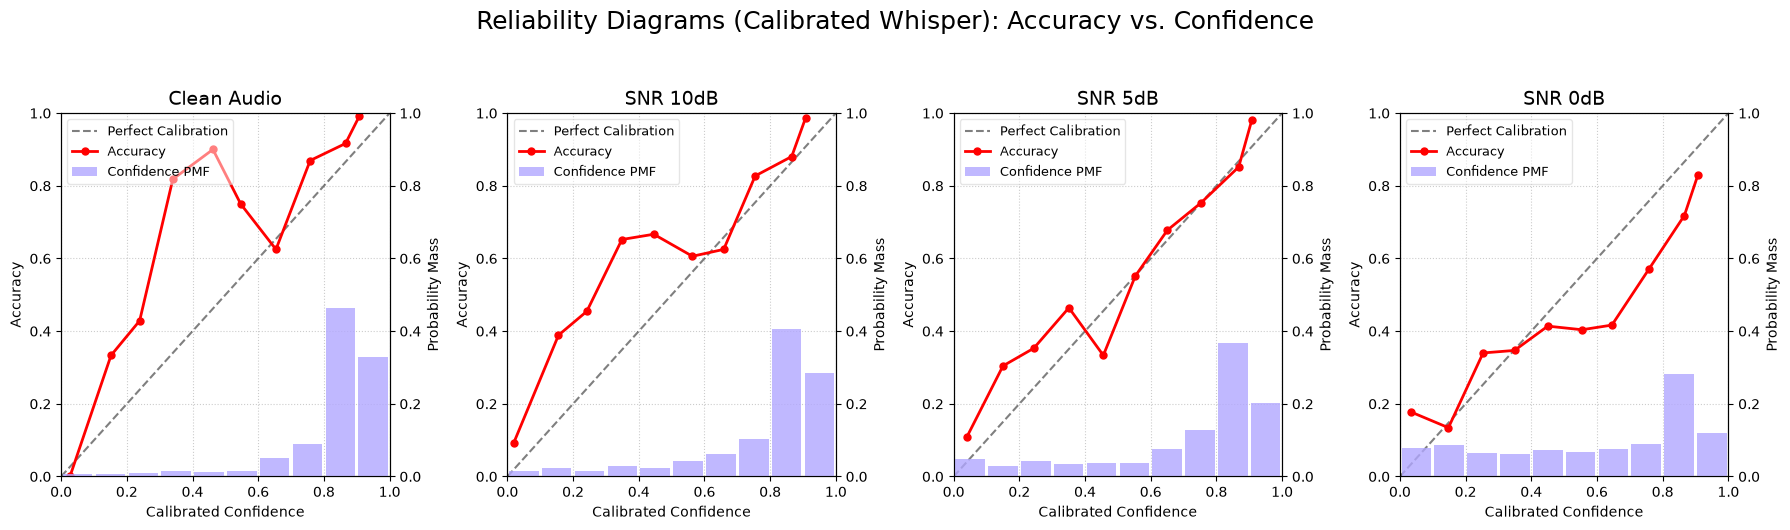

In [7]:
# 8. Plot Reliability Diagrams
num_bins = 10
bins = np.linspace(0, 1, num_bins + 1)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Reliability Diagrams (Calibrated Whisper): Accuracy vs. Confidence', fontsize=18, y=1.05)

for col_idx, snr in enumerate(snr_levels):
    ax1 = axes[col_idx]
    
    confidences = np.array([score for score, _ in results[snr]])
    labels = np.array([label for _, label in results[snr]])
    
    bin_accs, bin_confs, bin_masses = [], [], []
    
    for i in range(num_bins):
        bin_mask = (confidences >= bins[i]) & (confidences < bins[i + 1])
        bin_mass = np.sum(bin_mask) / len(confidences) if len(confidences) > 0 else 0
        bin_masses.append(bin_mass)
        
        if np.sum(bin_mask) > 0:
            bin_accs.append(np.mean(labels[bin_mask]))
            bin_confs.append(np.mean(confidences[bin_mask]))
        else:
            bin_accs.append(np.nan)
            bin_confs.append(np.nan)
            
    # PMF Bar Chart (Secondary Y-Axis)
    ax2 = ax1.twinx()
    width = 1.0 / num_bins
    bin_centers = bins[:-1] + width / 2
    
    bar_plot = ax2.bar(
        bin_centers, bin_masses, width=width * 0.9, 
        color='#b1a7ff', alpha=0.8, label='Confidence PMF'
    )
    ax2.set_ylabel("Probability Mass", color='black', fontsize=10)
    ax2.set_ylim(0, 1.0)
    
    # Accuracy Line Chart (Primary Y-Axis)
    ax1.plot([0, 1], [0, 1], linestyle='--', color='black', linewidth=1.5, label='Perfect Calibration', alpha=0.5)
    
    valid_idx = ~np.isnan(bin_accs)
    valid_confs = np.array(bin_confs)[valid_idx]
    valid_accs = np.array(bin_accs)[valid_idx]
    
    line_plot = ax1.plot(
        valid_confs, valid_accs, marker='o', color='red', 
        linewidth=2, markersize=5, label='Accuracy'
    )
    
    # Style
    title = f"Clean Audio" if snr == "clean" else f"SNR {snr}dB"
    ax1.set_title(title, fontsize=14, color='black')
    ax1.set_xlabel("Calibrated Confidence", fontsize=10, color='black')
    ax1.set_ylabel("Accuracy", color='black', fontsize=10)
    ax1.set_xlim(0.0, 1.0)
    ax1.set_ylim(0.0, 1.0)
    ax1.grid(axis="both", linestyle=":", alpha=0.4, color='gray')
    
    lines, labels_line = ax1.get_legend_handles_labels()
    bars, labels_bar = ax2.get_legend_handles_labels()
    ax1.legend(lines + bars, labels_line + labels_bar, loc="upper left", fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.show()